In [1]:
# This is going to be really similair to the OG versions of the IHC FISH attempt
# Goal to show fluoresence of Axl within each of our microglia.
# Ideally, graph the distribution of Axl fluorescence against the distribution of the different Solidities.

In [2]:
import os
from tqdm import tqdm

import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
import matplotlib.patches as patches

import tifffile as tiff
import cv2
import imageio.v2 as imageio
from anndata import AnnData

from skimage.morphology import skeletonize, opening, closing, disk, convex_hull_image
from scipy.ndimage import label, distance_transform_edt, binary_fill_holes
from skimage.morphology import remove_small_objects, skeletonize
from skimage.measure import find_contours, regionprops, regionprops_table, inertia_tensor, inertia_tensor_eigvals, label, perimeter
from skimage.segmentation import clear_border

from sklearn.linear_model import LinearRegression
from scipy.stats import linregress
from sklearn.metrics import r2_score
import re

In [3]:
def preprocess_and_segment(max_proj, window=101, disks=3):
    # Normalize and CLAHE
    max_proj_norm = cv2.normalize(max_proj, None, 0, 255, cv2.NORM_MINMAX).astype(np.uint8)
    clahe = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8, 8))
    clahe_img = clahe.apply(max_proj_norm)

    subtract = cv2.fastNlMeansDenoising(clahe_img)
    pre1 = cv2.adaptiveThreshold((255 - subtract), 255, cv2.ADAPTIVE_THRESH_GAUSSIAN_C,
                                  cv2.THRESH_BINARY, window, disks)

    opened = opening(255 - pre1, disk(disks))
    pre = closing(opened, disk(disks))
    filled_image = binary_fill_holes(pre).astype(np.uint8)
    #filled_image = pre
    size_threshold = 1000
    labeled_array = label(filled_image)
    cleaned = remove_small_objects(labeled_array, min_size=size_threshold)
    labeled_array = label(cleaned)

    return labeled_array

def find_soma_by_distance_transform(binary_image):
    distance_transform = distance_transform_edt(binary_image)
    skeleton = skeletonize(binary_image)
    skeleton_coords = np.column_stack(np.where(skeleton))
    max_distance_point = skeleton_coords[np.argmax(distance_transform[skeleton])]
    return max_distance_point, distance_transform, skeleton

def segment_soma(binary_image, soma_coords, distance_transform, threshold_ratio=0.5):
    threshold_value = distance_transform[soma_coords[0], soma_coords[1]] * threshold_ratio
    soma_segment = distance_transform >= threshold_value
    labeled_soma = label(soma_segment)
    soma_label = labeled_soma[soma_coords[0], soma_coords[1]]
    soma_region = labeled_soma == soma_label
    return soma_region

def compute_circularity(region_mask):
    area = np.sum(region_mask)
    perim = perimeter(region_mask)
    if perim == 0:
        return 0
    circularity = 4 * np.pi * area / (perim ** 2)
    return circularity

def is_soma_like(region_mask, circularity_threshold=0.5, area_threshold=100):
    circ = compute_circularity(region_mask)
    area = np.sum(region_mask)
    return circ > circularity_threshold and area > area_threshold

def calculate_solidity(binary_image):
    labeled = label(binary_image)
    props = regionprops(labeled)

    if not props:
        return np.nan

    largest = max(props, key=lambda r: r.area)
    region_mask = labeled == largest.label

    area = largest.area
    convex_area = np.sum(convex_hull_image(region_mask))

    if convex_area == 0:
        return np.nan

    return area / convex_area

def calculate_fractal_dimension(binary_image):
    def boxcount(Z, k):
        S = np.add.reduceat(
            np.add.reduceat(Z, np.arange(0, Z.shape[0], k), axis=0),
            np.arange(0, Z.shape[1], k), axis=1)
        return len(np.where((S > 0) & (S < k*k))[0])

    Z = binary_image > 0
    p = min(Z.shape)
    n = 2**np.floor(np.log2(p))
    n = int(np.log2(n))
    sizes = 2**np.arange(n, 1, -1)

    counts = []
    for size in sizes:
        counts.append(boxcount(Z, size))

    coeffs = np.polyfit(np.log(sizes), np.log(counts), 1)
    return -coeffs[0]

def keep_region(region_mask, area_threshold=100):
    """
    Return True if a region is big enough (or meets any other criteria you like).
    """
    return region_mask.sum() >= area_threshold

def filter_regions_with_soma(binary_mask, circularity_threshold=0.5, area_threshold=100, debug=False):
    labeled_mask = label(binary_mask)
    output_mask = np.zeros_like(binary_mask)
    soma_coords_list = []

    for region in regionprops(labeled_mask):
        region_mask = labeled_mask == region.label

        try:
            soma_coords, dist_transform, _ = find_soma_by_distance_transform(region_mask)
            soma_seg = segment_soma(region_mask, soma_coords, dist_transform)

            if is_soma_like(soma_seg, circularity_threshold, area_threshold):
                output_mask[region_mask] = region.label
                soma_coords_list.append(soma_coords)
        except Exception as e:
            print(f"Skipping region {region.label} due to error: {e}")

    if debug:
        # Plotting the filtered mask with soma centers
        plt.figure(figsize=(8, 8))
        plt.imshow(output_mask, cmap='nipy_spectral')
        for (y, x) in soma_coords_list:
            plt.plot(x, y, 'ro', markersize=5)  # x, y order
        plt.title("Filtered Regions with Soma Centers")
        plt.axis('off')
        plt.show()

    return output_mask

# ------------------------------------------------------------------
#  NEW: extract whole-cell masks only
# ------------------------------------------------------------------
def extract_whole_cell_masks(binary_mask,
                             area_threshold=100,
                             debug=False):
    """
    Parameters
    ----------
    binary_mask : 2-D bool
        Output of your Iba1 segmentation (max-projection mask).
    area_threshold : int
        Minimum pixel area for a region to be kept.
    debug : bool
        If True, shows an overlay figure.

    Returns
    -------
    results : list[dict]
        One dict per retained cell:
            • label_id   : connected-component label
            • cell_mask  : 2-D Boolean mask for the whole cell
            • area       : pixel area of the cell
    overlay_mask : 2-D uint16
        Same shape as input; each retained cell is painted with its label ID.
    """
    labeled_mask  = label(binary_mask)
    h, w          = binary_mask.shape
    overlay_mask  = np.zeros((h, w), dtype=np.uint16)
    results       = []

    for region in regionprops(labeled_mask):
        region_mask = labeled_mask == region.label

        # keep / discard rule (area, shape, intensity … anything you want)
        if not keep_region(region_mask, area_threshold):
            continue

        # record
        results.append({
            "label_id" : region.label,
            "cell_mask": region_mask,      # whole cell as one mask
            "area"     : int(region_mask.sum())
        })

        # paint overlay for visualization
        overlay_mask[region_mask] = region.label

    # ───────── optional QC plot ─────────
    if debug:
        plt.figure(figsize=(6, 6))
        plt.imshow(overlay_mask, cmap="nipy_spectral")
        plt.title("Whole-cell regions kept")
        plt.axis("off")
        plt.show()

    return results, overlay_mask

def segment_axl(test_axl):
    z_dim, y_dim, x_dim = test_axl.shape
    mask_3d = np.zeros((z_dim, y_dim, x_dim), dtype=np.uint8)

    # Iterate through each slice (plane) in the z-direction
    for z in range(z_dim):
        # Get the current slice (2D plane)
        plane = test_axl[z, :, :]
    
        # Normalize the slice to 0-255
        max_proj_norm = cv2.normalize(plane, None, 0, 255, cv2.NORM_MINMAX).astype(np.uint8)

        # Apply CLAHE (Contrast Limited Adaptive Histogram Equalization)
        clahe = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8, 8))
        clahe_img = clahe.apply(max_proj_norm)

        # Denoise using Non-Local Means Denoising
        subtract = cv2.fastNlMeansDenoising(clahe_img)

        # Apply thresholding (Otsu or adaptive thresholding)
        _, thresh = cv2.threshold(subtract, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)

        # Morphological operations
        opened = opening(thresh, disk(3))  # Opening: removes small noise
        closed = closing(opened, disk(3))  # Closing: fills small holes

        # Label connected components (objects)
        labeled, num_labels = label(closed, return_num=True)

        # Initialize a temporary mask for the current slice
        filtered_labels = np.zeros_like(labeled)

        # Iterate over labeled regions and filter by area (e.g., area > 50)
        regions = regionprops(labeled)
        for region in regions:
            if region.area > 50:  # Minimum area threshold (adjust as needed)
                filtered_labels[labeled == region.label] = region.label

        # Update the 3D mask with the binary mask for the current slice
        mask_3d[z, :, :] = (filtered_labels > 0).astype(np.uint8)
        
    return mask_3d

def quantify_axl_per_z_with_overlap(results,
                                    iba1_zstack,
                                    axl_zstack,
                                    mask_3d,  # 3D mask for overlap calculation
                                    min_seg_area=50,
                                    bg_sample_size=500):
    """
    Slice-wise area + AXL intensity, plus background, with overlap between 3D mask and Iba1.

    Parameters
    ----------
    results : list[dict]
        From `extract_whole_cell_masks`; each dict has
            • 'label_id'   int
            • 'cell_mask'  2-D bool  (whole cell on max-proj)
    iba1_zstack : ndarray (Z, H, W)
    axl_zstack  : ndarray (Z, H, W)      – fluorescence channel of interest
    mask_3d      : ndarray (Z, H, W)    – 3D mask to check overlap with
    min_seg_area : int                   – skip slice if Iba1 seg < this size
    bg_sample_size : int                 – # background pixels to average

    Returns
    -------
    pd.DataFrame with columns
        label_id, z, iba1_area_px, axl_intensity_sum, background_axl, axl_above_bg
    """

    Z, H, W = iba1_zstack.shape
    full_mask = np.zeros((H, W), dtype=bool)
    for c in results:
        full_mask |= c["cell_mask"]

    records = []

    for cell in results:
        label_id  = cell["label_id"]
        mask_2d   = cell["cell_mask"]

        # bounding box for speed
        ys, xs = np.nonzero(mask_2d)
        y0, y1 = ys.min(), ys.max()
        x0, x1 = xs.min(), xs.max()

        for z in range(Z):
            # 1) Iba1 segmentation inside crop
            iba1_patch = iba1_zstack[z, y0:y1+1, x0:x1+1]
            iba1_seg = preprocess_and_segment(iba1_patch, window=201, disks=1)

            if iba1_seg.sum() < min_seg_area:
                continue  # nothing on this slice

            # 2) AXL signal overlapping the Iba1 seg
            axl_patch = axl_zstack[z, y0:y1+1, x0:x1+1]
            axl_sum = float(axl_patch[iba1_seg].mean())  # average AXL intensity inside Iba1 region
            iba1_area = int(iba1_seg.sum())

            # 3) AXL signal overlapping the 3D mask
            axl_mask_sum = float(mask_3d[z, y0:y1+1, x0:x1+1][iba1_seg].sum())  # AXL intensity inside 3D mask

            # 4) Build background mask (global coords)
            bg_mask = np.ones((H, W), dtype=bool)
            bg_mask[y0:y1+1, x0:x1+1] = ~iba1_seg
            bg_mask &= ~full_mask

            # Sample & average background AXL intensity
            bg_yx = np.argwhere(bg_mask)
            if len(bg_yx) < bg_sample_size:
                continue  # not enough background; skip slice

            sel = bg_yx[np.random.choice(len(bg_yx), size=bg_sample_size, replace=False)]
            bg_axl = float(np.mean([axl_zstack[z, y, x] for y, x in sel]))

            # Determine if AXL intensity is above or below background for this slice
            axl_above_bg = "above" if axl_sum > bg_axl else "below"

            # Append results for the current slice
            records.append({
                "label_id": label_id,
                "z": z,
                "iba1_area_px": iba1_area,
                "axl_intensity_sum": axl_sum,
                "background_axl": bg_axl,
                "axl_above_bg": axl_above_bg,
                "axl_mask_sum": axl_mask_sum  # AXL intensity within the 3D mask
            })

    return pd.DataFrame(records)

def calculate_largest_region_fractal(labeled_array):
    regions = regionprops(labeled_array)
    if not regions:
        return np.nan
    # Pick the largest region
    largest = max(regions, key=lambda r: r.area)
    region_mask = labeled_array == largest.label
    return calculate_fractal_dimension(region_mask)

def process_axl_dataset(parent_dir,
                        area_threshold=275,
                        min_seg_area=50,
                        bg_sample_size=500,
                        debug_masks=False,
                        axl_percentile=95):
    """
    Traverse every sub-folder that contains “Axl”.
    • Threshold AXL channel at its 95-th percentile (values below ⇒ 0).
    • Per slice:    Iba1 area, AXL intensity, background mean  (via quantify_axl_per_z)
    • Per cell :    net_axl_sum  (background-subtracted total)
                    net_axl_per_px, shape metrics.
    """
    all_records = []

    for folder, _, files in os.walk(parent_dir):
        if "axl" not in folder.lower():
            continue                                    # skip unrelated folders

        # 1. build {P_label: {wl: path}}
        file_dict = {}
        for fname in files:
            m = re.match(r"(P_\d+)__([0-9]+)\.tif$", fname)
            if m:
                p_label, wl = m.groups()               # wl = "488" or "647"
                file_dict.setdefault(p_label, {})[wl] = os.path.join(folder, fname)

        # 2. iterate through positions
        for p_label, paths in tqdm(file_dict.items(),
                                   desc=f"Processing {folder}",
                                   leave=False):
            if not {"488", "647"} <= paths.keys():
                continue                               # need both channels

            try:
                iba1_stack = tiff.imread(paths["488"])
                axl_stack  = tiff.imread(paths["647"])

                # ── NEW: global 95-th-percentile threshold on AXL ─────────
                thr = np.percentile(axl_stack, axl_percentile)
                axl_stack_thr = np.where(axl_stack < thr, 0, axl_stack)

                # ── cell masks from max projection ───────────────────────
                max_proj    = iba1_stack.max(axis=0)
                iba1_cells  = preprocess_and_segment(max_proj)

                results, overlay_mask = extract_whole_cell_masks(
                    iba1_cells,
                    area_threshold=area_threshold,
                    debug=debug_masks
                )
                if not results:
                    continue

                # ── per-slice quantification ────────────────────────────
                mask_3d_axl = segment_axl(axl_stack)
                
                df_z = quantify_axl_per_z_with_overlap(
                    results,
                    iba1_stack,
                    axl_stack,
                    mask_3d_axl,
                    min_seg_area=min_seg_area,
                    bg_sample_size=bg_sample_size
                )
                if df_z.empty:
                    continue

                # net AXL per slice (background-subtracted)
                df_z["net_axl"] = df_z["axl_intensity_sum"]#(
                    #df_z["axl_intensity_sum"]
                    #- df_z["background_axl"] * df_z["iba1_area_px"]
                #)

                # ── aggregate one row per cell ───────────────────────────
                for cell in results:
                    label_id  = cell["label_id"]
                    mask      = overlay_mask == label_id
                    slice_rows = df_z[df_z.label_id == label_id]
                    if slice_rows.empty:
                        continue

                    iba1_area_sum = slice_rows.iba1_area_px.sum()
                    net_axl_sum   = slice_rows.net_axl.sum()
                    
                    region = regionprops(mask.astype(int))  # Ensure mask is in int format for regionprops
                    
                    x0, x1 = int(region[0].bbox[1]), int(region[0].bbox[3])
                    y0, y1 = int(region[0].bbox[0]), int(region[0].bbox[2])
                    
                    
                    bbox_region = mask[y0:y1, x0:x1]
            
                    # 1000 (old window) divided by vizgen pixel to micron divided by ours
                    canvas_size = 450
                    h, w = bbox_region.shape
            
                    if h > canvas_size or w > canvas_size:
                        continue
            
                    canvas = np.zeros((canvas_size, canvas_size), dtype=mask.astype(int).dtype)

                    # Center coordinates
                    y_offset = (canvas_size - h) // 2
                    x_offset = (canvas_size - w) // 2

                    # Paste into canvas
                    canvas[y_offset:y_offset + h, x_offset:x_offset + w] = bbox_region
                    
                    # Center coordinates
                    y_offset = (canvas_size - h) // 2
                    x_offset = (canvas_size - w) // 2
                    
                    
                    centroid_x = region[0].centroid[1]  # centroid[1] is the x-coordinate
                    centroid_y = region[0].centroid[0]  # centroid[0] is the y-coordinate
                    #print(mask.shape)

                    all_records.append({
                        "folder"             : folder,
                        "p_label"            : p_label,
                        "label_id"           : label_id,
                        # shape metrics
                        "fractal_dimension"  : calculate_largest_region_fractal(canvas),#calculate_fractal_dimension(mask),
                        "cell_solidity"      : calculate_solidity(mask),
                        # intensity metrics
                        "iba1_area_total_px" : iba1_area_sum,
                        "net_axl_sum"        : net_axl_sum,
                        "net_axl_per_px"     : (
                            net_axl_sum / iba1_area_sum
                            if iba1_area_sum > 0 else np.nan
                        ),
                        "axl_sum_mask": slice_rows.axl_mask_sum.sum(),
                        # Add centroid coordinates
                        "centroid_x"         : centroid_x,
                        "centroid_y"         : centroid_y
                    })

            except Exception as e:
                print(f"[ERROR] {folder}/{p_label}: {e}")
                continue

    return pd.DataFrame(all_records)

In [4]:
import scanpy as sc

# validating in transcriptome land
adata = sc.read_h5ad('Transciptomic_labels_and_morphology_labels_full.h5ad')

In [5]:
fractal = adata[adata.obs['ordered_morph'] == '3'].obs['Fractal Dimension'].mean()
solidity = adata[adata.obs['ordered_morph'] == '3'].obs['Cell Solidity'].mean()

In [6]:
df_cells = process_axl_dataset(
    "/hpc/projects/group.quake/doug/microglia_ihc_5262025",
    area_threshold=275,     
    min_seg_area=50,        
    bg_sample_size=500,    
    debug_masks=False      # Don't need an image output for every file
)

df_cells = df_cells[(df_cells.axl_sum_mask > 0) & (df_cells.folder != '/hpc/projects/group.quake/doug/microglia_ihc_5262025/24m_f_1_r1_Axl')]
df_cells["normalized_intensity"] = df_cells["net_axl_per_px"]
percentile = np.percentile(df_cells.normalized_intensity,62)

Processing /hpc/projects/group.quake/doug/microglia_ihc_5262025/24m_f_5_r1_Axl:   0%|          | 0/4 [00:00<?, ?it/s]        /tmp/ipykernel_3268434/3287337402.py:17: UserWarning: Only one label was provided to `remove_small_objects`. Did you mean to use a boolean array?
  cleaned = remove_small_objects(labeled_array, min_size=size_threshold)
Processing /hpc/projects/group.quake/doug/microglia_ihc_5262025/24m_f_5_r1_Axl:  75%|███████▌  | 3/4 [01:04<00:21, 21.13s/it]/tmp/ipykernel_3268434/3287337402.py:17: UserWarning: Only one label was provided to `remove_small_objects`. Did you mean to use a boolean array?
  cleaned = remove_small_objects(labeled_array, min_size=size_threshold)
Processing /hpc/projects/group.quake/doug/microglia_ihc_5262025/24m_f_3_r1_Axl:  75%|███████▌  | 3/4 [01:46<00:33, 33.47s/it]/tmp/ipykernel_3268434/3287337402.py:17: UserWarning: Only one label was provided to `remove_small_objects`. Did you mean to use a boolean array?
  cleaned = remove_small_objects(labeled_

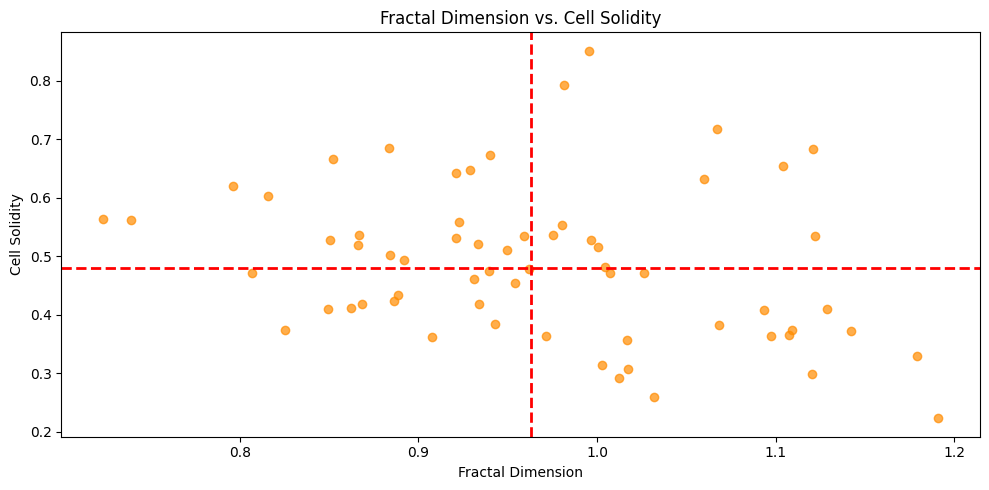

In [7]:
fig, axes = plt.subplots(1, 1, figsize=(10, 5))

axes.scatter(df_cells["fractal_dimension"],
                df_cells["cell_solidity"],
                alpha=0.7, color="darkorange")
axes.axhline(solidity, color="red", linestyle="--", linewidth=2)
axes.axvline(fractal, color='red', linestyle="--", linewidth=2)
axes.set_xlabel("Fractal Dimension")
axes.set_ylabel("Cell Solidity")
axes.set_title("Fractal Dimension vs. Cell Solidity")

plt.savefig('axl_ihc_out/axl_positive_morphologies.pdf', format='pdf')
plt.tight_layout()
plt.show()

# Plotting example image

In [8]:
#example images for segmentation

def create_color_rgb(gray_image, color='green'):
    """
    Convert grayscale image to RGB with specified color channel.
    
    Parameters:
    gray_image : numpy array
        Grayscale image (2D array)
    color : str
        Color channel to use: 'red', 'green', or 'blue'
    
    Returns:
    rgb_image : numpy array
        RGB image with specified color channel (3D array)
    """
    # Validate color input
    valid_colors = ['red', 'green', 'blue']
    if color.lower() not in valid_colors:
        raise ValueError(f"Color must be one of {valid_colors}, got '{color}'")
    
    # Normalize to 0-255 if not already
    if gray_image.max() <= 1.0:
        gray_norm = (gray_image * 255).astype(np.uint8)
    else:
        gray_norm = gray_image.astype(np.uint8)
    
    # Create RGB image: [Red, Green, Blue]
    rgb_image = np.zeros((gray_norm.shape[0], gray_norm.shape[1], 3), dtype=np.uint8)
    
    # Assign to appropriate channel based on color choice
    if color.lower() == 'red':
        rgb_image[:, :, 0] = gray_norm   # Red channel
        rgb_image[:, :, 1] = 0           # Green channel = 0
        rgb_image[:, :, 2] = 0           # Blue channel = 0
    elif color.lower() == 'green':
        rgb_image[:, :, 0] = 0           # Red channel = 0
        rgb_image[:, :, 1] = gray_norm   # Green channel
        rgb_image[:, :, 2] = 0           # Blue channel = 0
    elif color.lower() == 'blue':
        rgb_image[:, :, 0] = 0           # Red channel = 0
        rgb_image[:, :, 1] = 0           # Green channel = 0
        rgb_image[:, :, 2] = gray_norm   # Blue channel
    
    return rgb_image

def add_scale_bar(ax, image_shape, pixels_per_micron=4.1, scale_length_um=20, 
                  position='bottom-right', bar_color='white', text_color='white',
                  bar_height_pixels=6, margin_pixels=20, font_size=12):
    """
    Add a scale bar to a matplotlib axis showing a microscopy image.
    
    Parameters:
    -----------
    ax : matplotlib axis
        The axis to add the scale bar to
    image_shape : tuple
        (height, width) of the image
    pixels_per_micron : float
        Number of pixels per micron (default 4.1)
    scale_length_um : int
        Length of scale bar in microns (default 20)
    position : str
        Position of scale bar: 'bottom-right', 'bottom-left', 'top-right', 'top-left'
    bar_color : str
        Color of the scale bar rectangle
    text_color : str
        Color of the scale bar text
    bar_height_pixels : int
        Height of the scale bar in pixels
    margin_pixels : int
        Margin from image edge in pixels
    font_size : int
        Font size for scale bar text
    """
    
    # Calculate scale bar length in pixels
    scale_length_pixels = int(scale_length_um * pixels_per_micron)
    
    # Get image dimensions
    height, width = image_shape[:2]
    
    # Calculate position coordinates
    if position == 'bottom-right':
        x = width - scale_length_pixels - margin_pixels
        y = height - bar_height_pixels - margin_pixels
        text_x = x + scale_length_pixels / 2
        text_y = y - 10
        ha = 'center'
        va = 'top'
    elif position == 'bottom-left':
        x = margin_pixels
        y = height - bar_height_pixels - margin_pixels
        text_x = x + scale_length_pixels / 2
        text_y = y - 10
        ha = 'center'
        va = 'top'
    elif position == 'top-right':
        x = width - scale_length_pixels - margin_pixels
        y = margin_pixels
        text_x = x + scale_length_pixels / 2
        text_y = y + bar_height_pixels + 10
        ha = 'center'
        va = 'bottom'
    elif position == 'top-left':
        x = margin_pixels
        y = margin_pixels
        text_x = x + scale_length_pixels / 2
        text_y = y + bar_height_pixels + 10
        ha = 'center'
        va = 'bottom'
    else:
        raise ValueError("Position must be 'bottom-right', 'bottom-left', 'top-right', or 'top-left'")
    
    # Add scale bar rectangle
    rect = patches.Rectangle((x, y), scale_length_pixels, bar_height_pixels, 
                           linewidth=1, edgecolor=bar_color, facecolor=bar_color)
    ax.add_patch(rect)
    
    # Add scale bar text
    ax.text(text_x, text_y, f'{scale_length_um} μm', 
           color=text_color, fontsize=font_size, weight='bold',
           ha=ha, va=va)

In [9]:
iba1 = '/hpc/projects/group.quake/doug/microglia_ihc_5262025/24m_f_1_r1_Axl/P_1__488.tif'
axl = '/hpc/projects/group.quake/doug/microglia_ihc_5262025/24m_f_1_r1_Axl/P_1__647.tif'

In [10]:
z_stack488 = tiff.imread(iba1)
max_proj_488 = np.max(z_stack488, axis=0)
iba1_cells = preprocess_and_segment(max_proj_488)

iba1_zstack = tiff.imread(iba1)
axl_zstack = tiff.imread(axl)

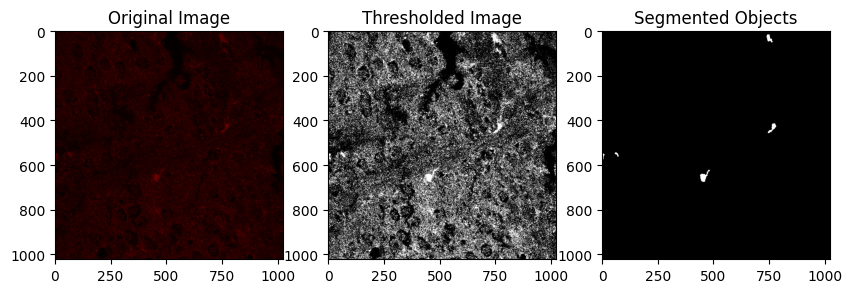

In [11]:
# Axl segmentation example

max_proj_norm = cv2.normalize(axl_zstack[10], None, 0, 255, cv2.NORM_MINMAX).astype(np.uint8)
clahe = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8, 8))
clahe_img = clahe.apply(max_proj_norm)
subtract = cv2.fastNlMeansDenoising(clahe_img)

_, thresh = cv2.threshold(subtract, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)
# Morphological operations
# Opening (erosion followed by dilation) to remove small noise
opened = opening(thresh, disk(3))  # Disk size can be adjusted

# Closing (dilation followed by erosion) to fill small holes
closed = closing(opened, disk(3))  # Disk size can be adjusted

# Label connected components (objects)
labeled, num_labels = label(closed, return_num=True)

# Now you can iterate over the labeled regions and filter out small/irrelevant objects
regions = regionprops(labeled)

# Optionally, filter by area (remove small regions or regions outside a size range)
filtered_labels = np.zeros_like(labeled)
for region in regions:
    if region.area > 100:  # Minimum area threshold (you can adjust this)
        filtered_labels[labeled == region.label] = region.label

# Final mask for the objects of interest
final_mask = (filtered_labels > 0).astype(np.uint8)

# Plot the results
plt.figure(figsize=(10, 6))

plt.subplot(1, 3, 1)
plt.title("Original Image")
plt.imshow(create_color_rgb(subtract, color='red'))

plt.subplot(1, 3, 2)
plt.title("Thresholded Image")
plt.imshow(thresh, cmap='gray')

plt.subplot(1, 3, 3)
plt.title("Segmented Objects")
plt.imshow(final_mask, cmap='gray')

plt.savefig('axl_ihc_out/axl_example_images.pdf', format='pdf')

plt.show()

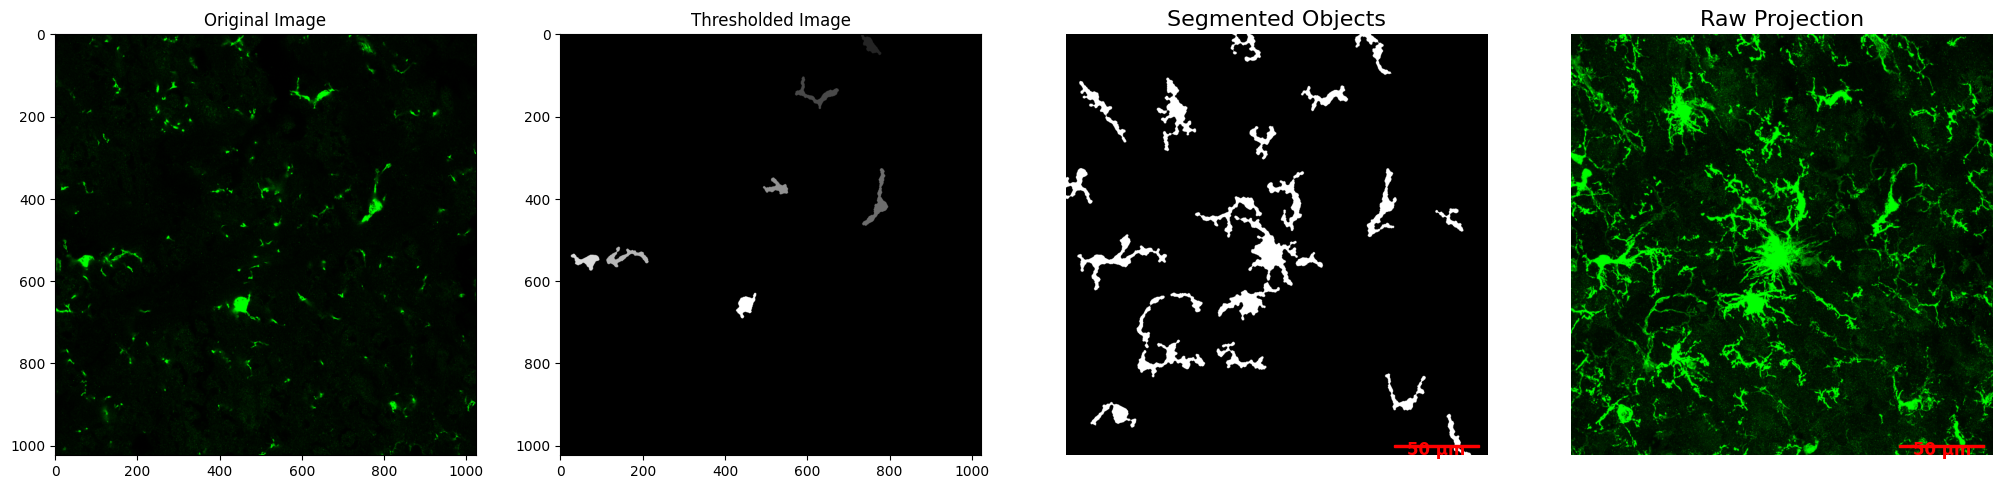

In [12]:
# Plot the results
results, overlay_mask = extract_whole_cell_masks(iba1_cells,debug=False)
plt.figure(figsize=(25, 15))
example = cv2.normalize(z_stack488[10], None, 0, 255, cv2.NORM_MINMAX).astype(np.uint8)

plt.subplot(1, 4, 1)
plt.title("Original Image")
plt.imshow(create_color_rgb(example, color='green'))

plt.subplot(1, 4, 2)
plt.title("Thresholded Image")
plt.imshow(preprocess_and_segment(example), cmap='gray')

plt.subplot(1, 4, 3)
plt.title("Segmented Objects", fontsize=16)
plt.imshow(overlay_mask.astype(bool), cmap='gray')
plt.axis('off')
add_scale_bar(plt.gca(), example.shape, pixels_per_micron=4.15, scale_length_um=50,
              position='bottom-right', bar_color='red', text_color='red')

example_max = cv2.normalize(np.max(z_stack488, axis=0), None, 0, 255, cv2.NORM_MINMAX).astype(np.uint8)

plt.subplot(1, 4, 4)
plt.title("Raw Projection", fontsize=16)
plt.imshow(create_color_rgb(example_max, color='green'))
plt.axis('off')
add_scale_bar(plt.gca(), example_max.shape, pixels_per_micron=4.15, scale_length_um=50,
              position='bottom-right', bar_color='red', text_color='red')

plt.savefig('axl_ihc_out/axl_example_images_iba1.pdf', format='pdf')

plt.show()